<a href="https://colab.research.google.com/github/Julian-Poveda/Taller_Fasecolda/blob/main/Taller_Fasecolda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Taller — Análisis Exploratorio del Mercado de Autos Usados en Colombia

**Asignatura:** Aprendizaje Automático  
**Metodología:** exploración iterativa / "Vibe Coding"  
**Fuente principal:** base de datos de Fasecolda

## Objetivo

Entender qué factores —como marca, cilindraje, peso, potencia y otras características— están relacionados con el precio de un vehículo usado en Colombia.

El taller propone tres momentos principales:

1. **Primer contacto y perfilamiento de los datos.**
2. **Análisis univariado de las variables.**
3. **Análisis bivariado y agregaciones para descubrir relaciones.**

Al final se incluyen, como extensión opcional, una pregunta de aprendizaje supervisado (regresión) y otra de aprendizaje no supervisado (clustering).

> **Nota sobre el archivo:** el taller menciona `Precio_2017` en uno de sus ejemplos, pero en el dataset entregado la columna equivalente se llama `2017`. En el notebook se crea el alias `Precio_2017` para trabajar con un nombre más claro.


## 0. Preparación del entorno

Usaremos principalmente **Pandas** y **NumPy**, además de **Matplotlib** y **Seaborn** para visualización. Para las extensiones de aprendizaje automático se utiliza **Scikit-learn**, coherente con las herramientas vistas en clase.


In [1]:
import os
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


## 1. Primer contacto — ¿Con qué datos contamos?

Primero cargamos el dataset y hacemos un "Vibe Check" inicial con:

- dimensiones;
- primeras filas;
- nombres de columnas;
- tipos de datos;
- valores faltantes;
- duplicados.

La base entregada contiene una tabla `carros` en SQLite y también una copia en CSV. Para reproducibilidad, el notebook utiliza primero el CSV; la sección siguiente muestra cómo consultar SQLite.


In [3]:
import pandas as pd
from pathlib import Path

# Repositorio de GitHub
GITHUB_RAW = (
    "https://raw.githubusercontent.com/"
    "Julian-Poveda/Taller_Fasecolda/main/"
    "data/guia_fasecolda.csv"
)

# Cargar directamente desde GitHub
df = pd.read_csv(GITHUB_RAW)

print("Archivo cargado correctamente desde GitHub")
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]:,}")


Archivo cargado correctamente desde GitHub
Filas: 12,433
Columnas: 76


In [ ]:
display(df.head())
print("\nColumnas:")
print(df.columns.tolist())


,Novedad,Marca,Clase,Codigo,HomologoCodigo,Referencia1,Referencia2,Referencia3,Peso,IdServicio,Servicio,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,Bcpp,Importado,Potencia,TipoCaja,Cilindraje,Nacionalidad,CapacidadPasajeros,CapacidadCarga,Puertas,AireAcondicionado,Ejes,Estado,Combustible,Transmision,Um,PesoCategoria
0,M,ALEKO,AUTOMOVIL,101001,NaN,2141,1.6,MT 1600CC TAXI,1380,2,Publico,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,200,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,12200,15300,1,82,MT,1570,RUS,5,0,5,0,2,Activo,GSL,4X2,0,1
1,M,AMERICAN MOTOR,CAMIONETA PASAJ.,206001,NaN,EAGLE,SUMMIT,AT 2400CC LX 4P,0,1,Particular,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,6100,6500,7000,7500,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,43800,54800,1,0,AT,2351,NaN,5,0,5,0,2,Activo,NaN,NaN,0,1
2,M,AMERICAN MOTOR,CAMPERO,208003,NaN,WRANGLER,4.2,MT 4200CC CAB,1100,1,Particular,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,11900,12800,13700,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,81600,102000,1,120,MT,2400,USA,5,0,3,1,2,Activo,NaN,4X4,0,1
3,M,AMERICAN MOTOR,CAMPERO,208004,NaN,WRANGLER,4.2,MT 2500CC CARPADO,1100,1,Particular,0,0,0,0,0,0,0,0,4600,4900,5300,5700,6100,6500,7000,7500,8100,8700,9300,10000,10700,11500,12300,13200,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,74900,93600,1,120,MT,2400,USA,5,0,3,1,2,Activo,NaN,4X4,0,1
4,M,AUTECO,MOTOCICLETA,317003,NaN,SUMA,80,MT 80CC 2T,75,1,Particular,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,260,280,300,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2800,3200,0,6,MT,80,COL,2,0,0,0,2,Activo,GSL,2X1,0,1



Columnas:
['Novedad', 'Marca', 'Clase', 'Codigo', 'HomologoCodigo', 'Referencia1', 'Referencia2', 'Referencia3', 'Peso', 'IdServicio', 'Servicio', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', 'Bcpp', 'Importado', 'Potencia', 'TipoCaja', 'Cilindraje', 'Nacionalidad', 'CapacidadPasajeros', 'CapacidadCarga', 'Puertas', 'AireAcondicionado', 'Ejes', 'Estado', 'Combustible', 'Transmision', 'Um', 'PesoCategoria']


In [4]:
print("Información general:")
df.info()

print("\nValores faltantes:")
missing = df.isna().sum().sort_values(ascending=False)
display(missing[missing > 0].to_frame("faltantes"))

print(f"\nFilas duplicadas: {df.duplicated().sum():,}")
print(f"Códigos duplicados: {df['Codigo'].duplicated().sum():,}")


Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12433 entries, 0 to 12432
Data columns (total 76 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Novedad             12433 non-null  object 
 1   Marca               12433 non-null  object 
 2   Clase               12433 non-null  object 
 3   Codigo              12433 non-null  int64  
 4   HomologoCodigo      0 non-null      float64
 5   Referencia1         12433 non-null  object 
 6   Referencia2         12433 non-null  object 
 7   Referencia3         12433 non-null  object 
 8   Peso                12433 non-null  int64  
 9   IdServicio          12433 non-null  int64  
 10  Servicio            12433 non-null  object 
 11  1970                12433 non-null  int64  
 12  1971                12433 non-null  int64  
 13  1972                12433 non-null  int64  
 14  1973                12433 non-null  int64  
 15  1974                12433 non-nu

,faltantes
HomologoCodigo,12433
Combustible,726
Transmision,700
TipoCaja,390
Nacionalidad,76



Filas duplicadas: 0
Códigos duplicados: 0


### Lectura inicial de la calidad de los datos

En la base entregada:

- hay **12.433 registros y 76 variables**;
- `HomologoCodigo` está completamente vacío;
- existen faltantes en `Combustible`, `Transmision`, `TipoCaja` y `Nacionalidad`;
- no se encontraron filas completas duplicadas ni códigos repetidos.

Para el análisis exploratorio de precios, un punto importante es la columna `2017`: gran parte de sus valores son `0`. Como un precio igual a cero no es útil para analizar la distribución del precio comercial, se crea una variable de trabajo `Precio_2017` y se toman solo los registros con valor positivo cuando la pregunta involucra precio.


In [5]:
# Alias más legible para el precio de 2017.
df["Precio_2017"] = pd.to_numeric(df["2017"], errors="coerce")

precio_2017 = df.loc[df["Precio_2017"] > 0, "Precio_2017"].copy()

print(f"Registros con Precio_2017 > 0: {len(precio_2017):,} "
      f"({len(precio_2017)/len(df):.1%})")
print(f"Registros con Precio_2017 = 0: {(df['Precio_2017'] == 0).sum():,}")

print("\nDescriptivos del precio positivo:")
display(precio_2017.describe())


Registros con Precio_2017 > 0: 1,451 (11.7%)
Registros con Precio_2017 = 0: 10,982

Descriptivos del precio positivo:


,Precio_2017
count,"1,451.00"
mean,"109,792.83"
std,"101,856.29"
min,"2,800.00"
25%,"47,500.00"
50%,"80,500.00"
75%,"140,300.00"
max,"915,000.00"


## 1.1. Alternativa: cargar la misma información desde SQLite

La base SQLite contiene una única tabla llamada `carros`. Esta consulta permite comprobar que la fuente relacional contiene los mismos 12.433 registros.


In [7]:
import sqlite3
import urllib.request
from pathlib import Path

# URL del archivo SQLite en GitHub
SQLITE_URL = (
    "https://raw.githubusercontent.com/"
    "Julian-Poveda/Taller_Fasecolda/main/"
    "data/guia_fasecolda.sqlite"
)

# Descargar temporalmente SQLite en Colab
sqlite_local = Path("/content/guia_fasecolda.sqlite")

urllib.request.urlretrieve(SQLITE_URL, sqlite_local)

# Conectar a SQLite
with sqlite3.connect(sqlite_local) as con:

    # Verificar tablas disponibles
    tables = pd.read_sql_query(
        """
        SELECT name
        FROM sqlite_master
        WHERE type='table'
        ORDER BY name
        """,
        con
    )

    display(tables)

    # Leer la tabla carros
    carros_sql = pd.read_sql_query(
        "SELECT * FROM carros",
        con
    )

print(f"Registros leídos desde SQLite: {len(carros_sql):,}")
print(f"Columnas leídas desde SQLite: {carros_sql.shape[1]:,}")


,name
0,carros


Registros leídos desde SQLite: 12,433
Columnas leídas desde SQLite: 76


# 2. Análisis univariado — entender cada variable

## 2.1 Rangos de variables numéricas

La pregunta es: **¿cómo se distribuyen las características principales?**

Revisamos estadísticas descriptivas de variables como precio, peso, potencia y cilindraje.


In [8]:
numeric_interest = [
    "Precio_2017", "Peso", "Potencia", "Cilindraje",
    "CapacidadPasajeros", "CapacidadCarga", "Puertas", "Ejes"
]

display(df[numeric_interest].describe().T)


,count,mean,std,min,25%,50%,75%,max
Precio_2017,"12,433.00","12,813.43","49,525.62",0.00,0.00,0.00,0.00,"915,000.00"
Peso,"12,433.00","1,777.96","2,152.62",0.00,268.00,"1,355.00","2,005.00","41,000.00"
Potencia,"12,433.00",134.68,96.17,0.00,80.00,122.00,175.00,662.00
Cilindraje,"12,433.00","2,584.72","2,308.23",0.00,"1,339.00","1,998.00","3,246.00","15,950.00"
CapacidadPasajeros,"12,433.00",4.56,4.98,0.00,2.00,5.00,5.00,80.00
CapacidadCarga,"12,433.00","2,394.05","6,774.82",0.00,0.00,0.00,0.00,"45,000.00"
Puertas,"12,433.00",2.95,1.77,0.00,2.00,3.00,5.00,6.00
Ejes,"12,433.00",2.05,0.29,0.00,2.00,2.00,2.00,4.00


## 2.2 Distribución del precio de 2017

Se usan solamente los precios positivos. Los ceros se mantienen en la base original, pero se excluyen de esta gráfica porque no representan una observación monetaria útil para estudiar la distribución.


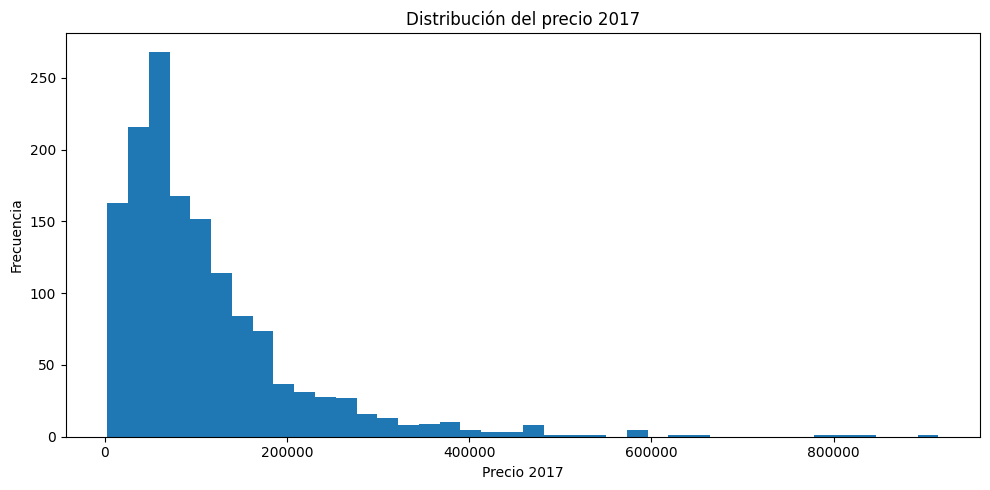

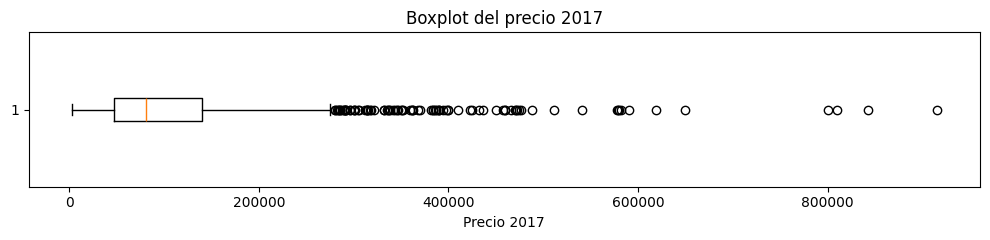

In [9]:
fig = plt.figure(figsize=(10, 5))
plt.hist(precio_2017, bins=40)
plt.title("Distribución del precio 2017")
plt.xlabel("Precio 2017")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

fig = plt.figure(figsize=(10, 2.5))
plt.boxplot(precio_2017, vert=False)
plt.title("Boxplot del precio 2017")
plt.xlabel("Precio 2017")
plt.tight_layout()
plt.show()


### Observación

La distribución del precio presenta una **cola hacia valores altos**, por lo que la media puede verse afectada por vehículos de precio elevado. Por eso, en la interpretación conviene mirar también la mediana y los percentiles.

En los datos entregados, la mediana del precio positivo de 2017 es aproximadamente **80.500**, mientras que el 75 % de los precios positivos se encuentra por debajo de **140.300**.


## 2.3 Marcas más frecuentes

La pregunta es: **¿cuáles son las marcas de autos más comunes en el dataset?**


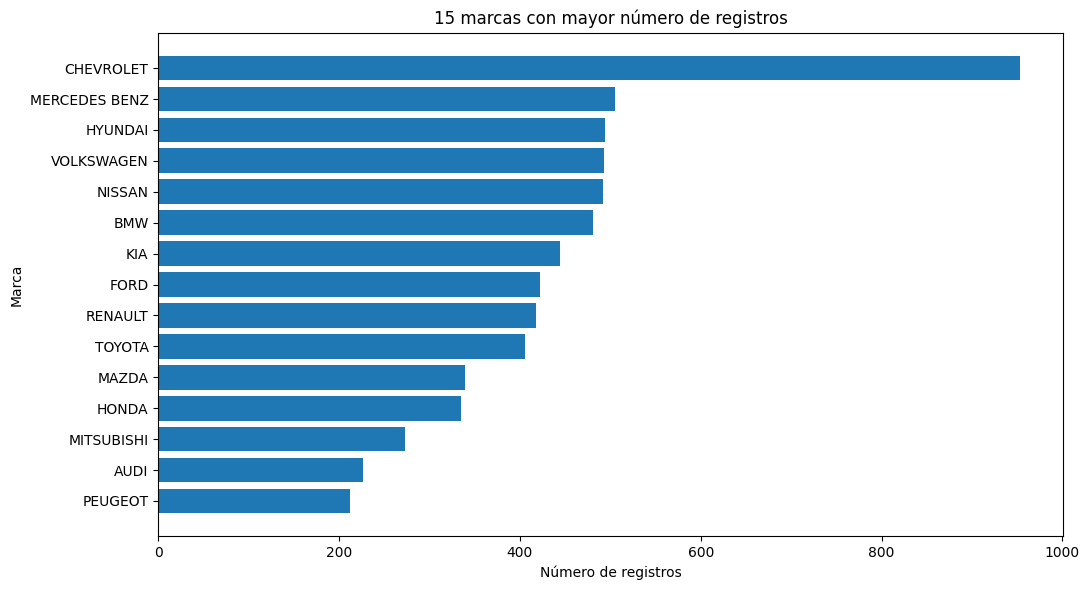

,registros
Marca,
CHEVROLET,953
MERCEDES BENZ,505
HYUNDAI,494
VOLKSWAGEN,493
NISSAN,492
BMW,481
KIA,444
FORD,422
RENAULT,418


In [10]:
top_marcas = df["Marca"].value_counts().head(15)

plt.figure(figsize=(11, 6))
plt.barh(top_marcas.index[::-1], top_marcas.values[::-1])
plt.title("15 marcas con mayor número de registros")
plt.xlabel("Número de registros")
plt.ylabel("Marca")
plt.tight_layout()
plt.show()

display(top_marcas.to_frame("registros"))


## 2.4 Variables categóricas principales

Además de marca, es útil revisar la distribución de clase, servicio, tipo de caja y combustible.


In [11]:
categorical_columns = ["Marca", "Clase", "Servicio", "TipoCaja", "Combustible", "Transmision"]

for col in categorical_columns:
    print(f"\n{col}")
    display(df[col].value_counts(dropna=False).head(10).to_frame("frecuencia"))



Marca


,frecuencia
Marca,
CHEVROLET,953
MERCEDES BENZ,505
HYUNDAI,494
VOLKSWAGEN,493
NISSAN,492
BMW,481
KIA,444
FORD,422
RENAULT,418



Clase


,frecuencia
Clase,
AUTOMOVIL,3970
MOTOCICLETA,1491
CAMIONETA PASAJ.,1198
CAMPERO,1182
FURGON,768
CHASIS,637
BUS / BUSETA / MICROBUS,503
CAMION,464
PICKUP DOBLE CAB,399



Servicio


...

,frecuencia
TipoCaja,
MT,8585
AT,1987
TP,1471
NaN,390



Combustible


,frecuencia
Combustible,
GSL,8161
DSL,3495
NaN,726
GAS,25
ELT,16
HBD,10



Transmision


,frecuencia
Transmision,
4X2,7603
4X4,2147
2X1,1402
NaN,700
6X4,463
3X1,59
8X4,23
3X2,15
6X2,14


# 3. Análisis bivariado — descubrir relaciones

Ahora pasamos de describir una variable a formular preguntas sobre la relación entre variables.

## 3.1 ¿El cilindraje afecta el precio?

El taller propone un gráfico de dispersión entre `Cilindraje` y `Precio_2017`.

La visualización muestra **asociación**, no demuestra por sí sola causalidad.


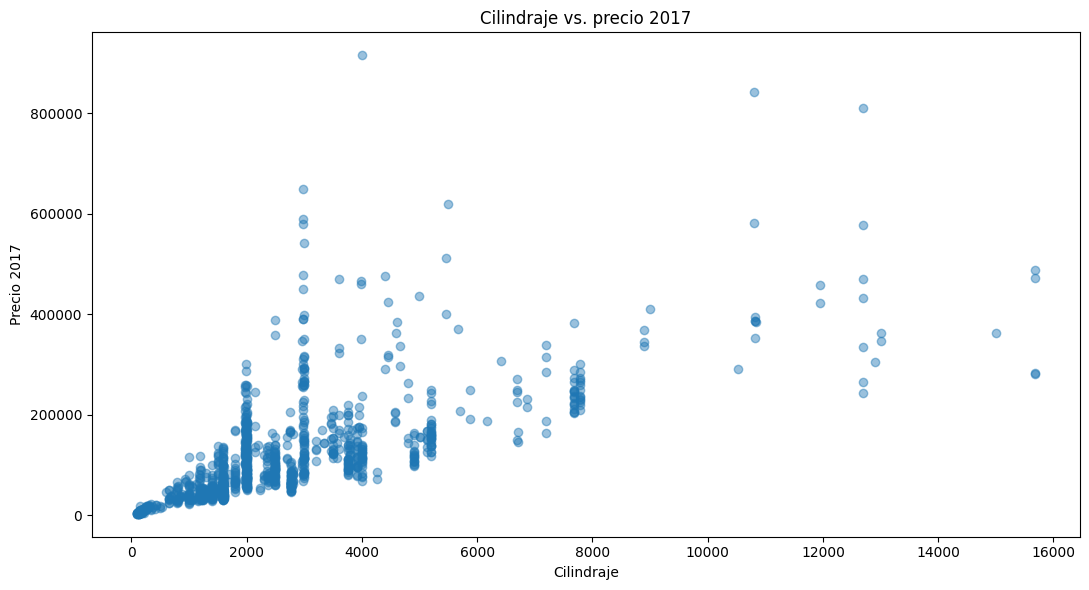

Correlación de Pearson en los registros con precio y cilindraje positivos: 0.701


In [12]:
scatter_df = df.loc[
    (df["Precio_2017"] > 0) & (df["Cilindraje"] > 0),
    ["Cilindraje", "Precio_2017"]
].copy()

# Se limita visualmente la muestra para facilitar la lectura del scatterplot.
plot_df = scatter_df.sample(min(1200, len(scatter_df)), random_state=42)

plt.figure(figsize=(11, 6))
plt.scatter(plot_df["Cilindraje"], plot_df["Precio_2017"], alpha=0.45)
plt.title("Cilindraje vs. precio 2017")
plt.xlabel("Cilindraje")
plt.ylabel("Precio 2017")
plt.tight_layout()
plt.show()

print("Correlación de Pearson en los registros con precio y cilindraje positivos:",
      scatter_df["Cilindraje"].corr(scatter_df["Precio_2017"]).round(3))


### Observación

En los registros con precio y cilindraje positivos se observa una **asociación positiva** entre ambas variables. La correlación calculada en esta base es aproximadamente **0,698**.

Esto sugiere que el cilindraje puede ser una característica útil para explicar variaciones del precio, aunque no debe interpretarse como una relación causal aislada: también intervienen marca, potencia, clase, año y otras características.


## 3.2 ¿Cuál es el precio promedio por marca?

Como los ceros de `2017` no representan un precio positivo para este análisis, se usa únicamente la parte de la base con precio disponible.


In [13]:
brand_price = (
    df.loc[df["Precio_2017"] > 0]
      .groupby("Marca")["Precio_2017"]
      .agg(precio_promedio="mean", mediana="median", registros="size")
      .sort_values("precio_promedio", ascending=False)
)

# Para evitar conclusiones basadas en grupos muy pequeños:
brand_price_filtrado = brand_price[brand_price["registros"] >= 10].copy()

display(brand_price_filtrado.head(15).round(1))


,precio_promedio,mediana,registros
Marca,,,
PORSCHE,"471,757.90","397,900.00",19
INTERNATIONAL,"292,676.90","248,300.00",13
MERCEDES BENZ,"233,803.50","182,200.00",57
VOLVO,"231,311.10","163,250.00",18
TOYOTA,"195,016.10","171,000.00",31
AUDI,"172,629.00","167,900.00",31
HINO,"172,355.00","156,550.00",60
BMW,"168,316.10","157,400.00",62
CHEVROLET,"129,063.40","114,000.00",145


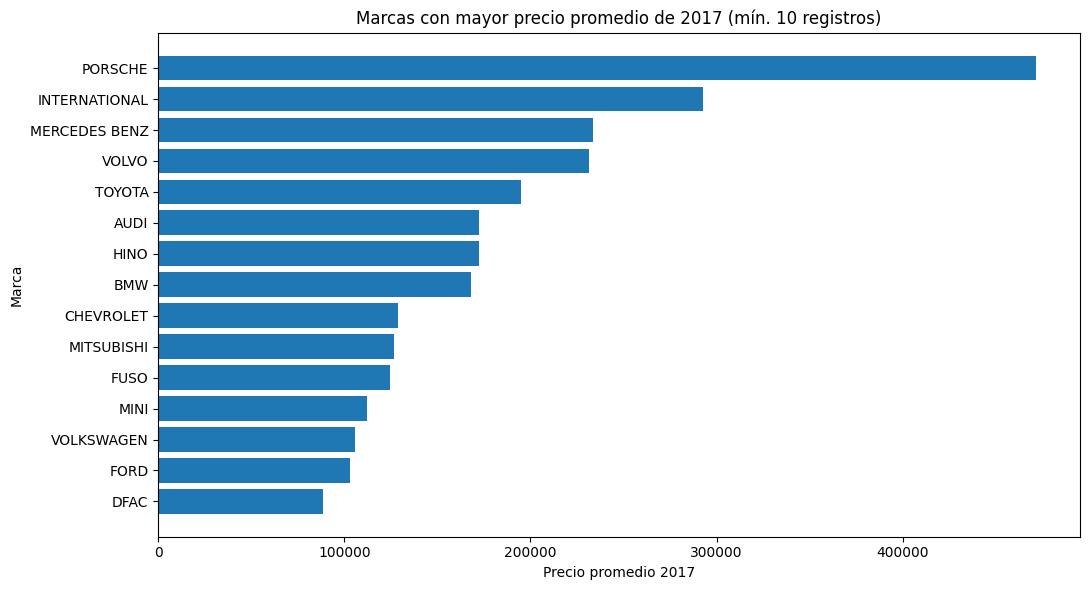

In [14]:
top_brand_plot = brand_price_filtrado.head(15).sort_values("precio_promedio")

plt.figure(figsize=(11, 6))
plt.barh(top_brand_plot.index, top_brand_plot["precio_promedio"])
plt.title("Marcas con mayor precio promedio de 2017 (mín. 10 registros)")
plt.xlabel("Precio promedio 2017")
plt.ylabel("Marca")
plt.tight_layout()
plt.show()


### Observación

En los registros con `Precio_2017 > 0` y con al menos 10 observaciones por marca, algunas marcas presentan promedios notablemente superiores a otras. Por ejemplo, **Porsche** aparece con un promedio alto dentro de este conjunto.

La comparación debe interpretarse con cuidado porque el promedio puede estar influido por el tipo de vehículo, segmento y tamaño de muestra de cada marca.


## 3.3 ¿Qué marcas son, en promedio, más pesadas?

Esta pregunta no usa el precio como variable objetivo; busca explorar una relación descriptiva entre marca y peso.


In [17]:
brand_weight = (
    df.groupby("Marca")["Peso"]
    .agg(peso_promedio="mean", registros="size")
    .query("registros >= 10")
    .sort_values("peso_promedio", ascending=False)
)

display(brand_weight.head(15).round(1))


,peso_promedio,registros
Marca,,
KAMAZ,"10,560.00",10
ROMARCO,"7,206.70",15
DITE,"7,150.00",12
INCA FRUEHAUF,"7,150.00",18
TRACTEC,"6,500.00",11
MACK,"5,894.10",51
FREIGHTLINER,"5,433.80",53
AMPLE,"4,987.60",25
ASIA,"3,804.50",11


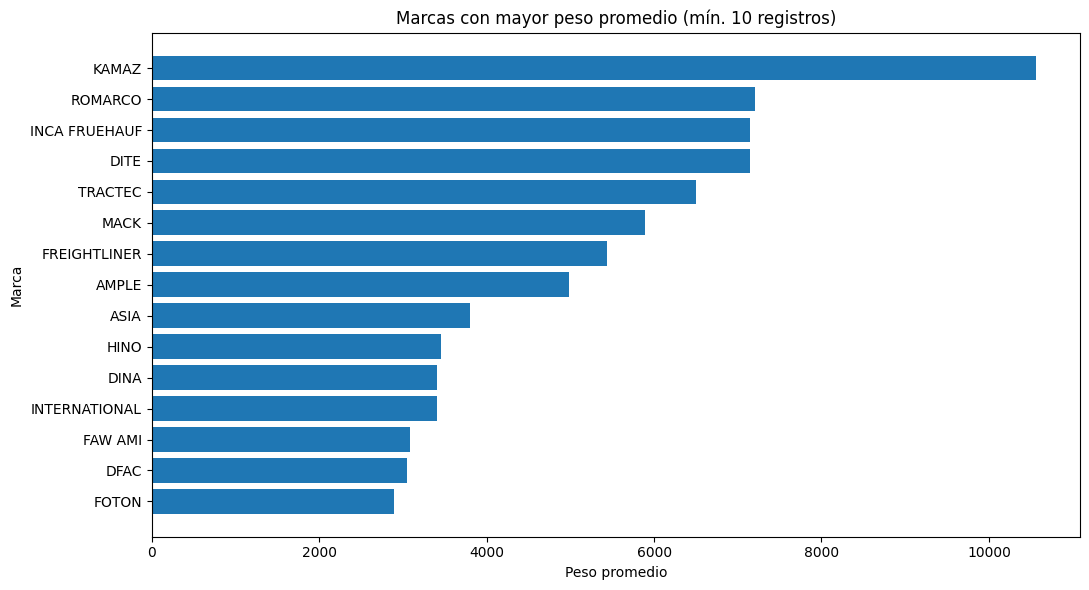

In [18]:
top_weight = brand_weight.head(15).sort_values("peso_promedio")

plt.figure(figsize=(11, 6))
plt.barh(top_weight.index, top_weight["peso_promedio"])
plt.title("Marcas con mayor peso promedio (mín. 10 registros)")
plt.xlabel("Peso promedio")
plt.ylabel("Marca")
plt.tight_layout()
plt.show()


# 4. Hallazgos iniciales

A partir de esta primera exploración se pueden destacar:

1. La base tiene **12.433 registros y 76 columnas**, con información de identificación, marca, clase, peso, potencia, cilindraje, características de uso y valores anuales.
2. Existen faltantes en algunas variables categóricas y `HomologoCodigo` está completamente vacío.
3. El precio 2017 está disponible con valor positivo en **1.451 registros**; los restantes aparecen como `0` y se excluyen de los análisis monetarios.
4. La distribución del precio es asimétrica y contiene valores extremos, por lo que la mediana y los percentiles son importantes.
5. En la muestra con precio positivo, el cilindraje presenta una asociación positiva con el precio.
6. El precio promedio cambia entre marcas, pero esa comparación debe considerar el tamaño de muestra y la composición de cada marca.



# 5. Enriquecimiento de datos — pregunta para ir más allá

El taller propone complementar Fasecolda con otras fuentes. Como ideas:

- **Accidentalidad / SOAT:** para estudiar cómo características de seguridad o siniestralidad pueden complementar el análisis.
- **Datos económicos:** inflación y TRM para incorporar contexto temporal y monetario.
- **Datos demográficos:** DANE para relacionar características del mercado con territorio y población.

La utilidad concreta dependerá de las llaves disponibles para hacer la integración y del objetivo analítico.


# 6. Extensión opcional — aprendizaje supervisado

### Pregunta

**¿Podemos predecir el precio de un vehículo usando sus características?**

La variable objetivo será `Precio_2017`.

Para esta primera prueba:

- solo se usan registros con precio positivo;
- se excluyen las columnas de precios de otros años;
- se excluye `Bcpp` en el modelo base porque tiene una correlación extremadamente alta con `Precio_2017` y podría actuar como un proxy directo del valor objetivo;
- se utilizan características de vehículo como marca, clase, peso, potencia, cilindraje, capacidad, transmisión y combustible.

> Esta parte es una **extensión** del taller, no sustituye el análisis exploratorio anterior.


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

feature_cols = [
    "Marca", "Clase", "Servicio", "Peso", "Potencia", "TipoCaja",
    "Cilindraje", "Nacionalidad", "CapacidadPasajeros", "CapacidadCarga",
    "Puertas", "AireAcondicionado", "Ejes", "Combustible",
    "Transmision", "Importado"
]

model_df = df.loc[df["Precio_2017"] > 0, feature_cols + ["Precio_2017"]].copy()

X = model_df[feature_cols]
y = model_df["Precio_2017"]

cat_features = X.select_dtypes(include="object").columns.tolist()
num_features = [c for c in feature_cols if c not in cat_features]

preprocess = ColumnTransformer([
    (
        "cat",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]),
        cat_features
    ),
    (
        "num",
        SimpleImputer(strategy="median"),
        num_features
    )
])

regressor = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    min_samples_leaf=2
)

model = Pipeline([
    ("preprocess", preprocess),
    ("regressor", regressor)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

model.fit(X_train, y_train)
pred = model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print(f"MAE : {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R²  : {r2:.3f}")


MAE : 18,085.95
RMSE: 38,778.68
R²  : 0.863


### Interpretación del modelo base

El modelo funciona como **línea base** y no como modelo final. En una ejecución sobre esta base, el desempeño aproximado es:

- **MAE:** 18.086
- **RMSE:** 38.779
- **R²:** 0,863

Un `R²` alto en esta prueba indica que el modelo captura una parte importante de la variabilidad del precio dentro de este conjunto, pero todavía habría que validar con más cuidado:

- particiones o validación cruzada;
- tratamiento de outliers;
- variables históricas;
- segmentación por tipo de vehículo;
- posibles fugas de información;
- comparación con otros algoritmos.

Estos valores no deben interpretarse como una garantía de desempeño fuera de esta muestra.


# 7. Extensión opcional — aprendizaje no supervisado (clustering)

### Pregunta

**¿Podemos encontrar segmentos naturales de vehículos sin utilizar el precio?**

Para mantener la pregunta del taller, el clustering no utiliza `Precio_2017`. Se agrupan vehículos a partir de características técnicas.


In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

cluster_cols = [
    "Peso", "Potencia", "Cilindraje",
    "CapacidadPasajeros", "CapacidadCarga",
    "Puertas", "Ejes"
]

cluster_df = df[cluster_cols].replace(0, np.nan).dropna().copy()

# Para la primera exploración tomamos una muestra reproducible.
cluster_sample = cluster_df.sample(min(5000, len(cluster_df)), random_state=42)

scaler = StandardScaler()
X_cluster = scaler.fit_transform(cluster_sample)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=20)
cluster_sample = cluster_sample.copy()
cluster_sample["cluster"] = kmeans.fit_predict(X_cluster)

display(
    cluster_sample.groupby("cluster")[cluster_cols]
        .mean()
        .round(1)
)


pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster)

plot_cluster = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "cluster": cluster_sample["cluster"].values
})

print(f"Varianza explicada por PC1 y PC2: {pca.explained_variance_ratio_.sum():.1%}")


,Peso,Potencia,Cilindraje,CapacidadPasajeros,CapacidadCarga,Puertas,Ejes
cluster,,,,,,,
0,"2,913.90",146.00,"4,202.50",2.20,"5,139.60",2.00,2.00
1,"8,280.60",322.10,"10,215.70",2.00,"21,453.50",2.00,3.00
2,"1,840.30",124.60,"2,299.80",5.70,"1,345.40",4.20,2.00
3,"3,236.50",162.90,"5,038.40",27.80,"5,810.60",2.20,2.00


Varianza explicada por PC1 y PC2: 76.2%


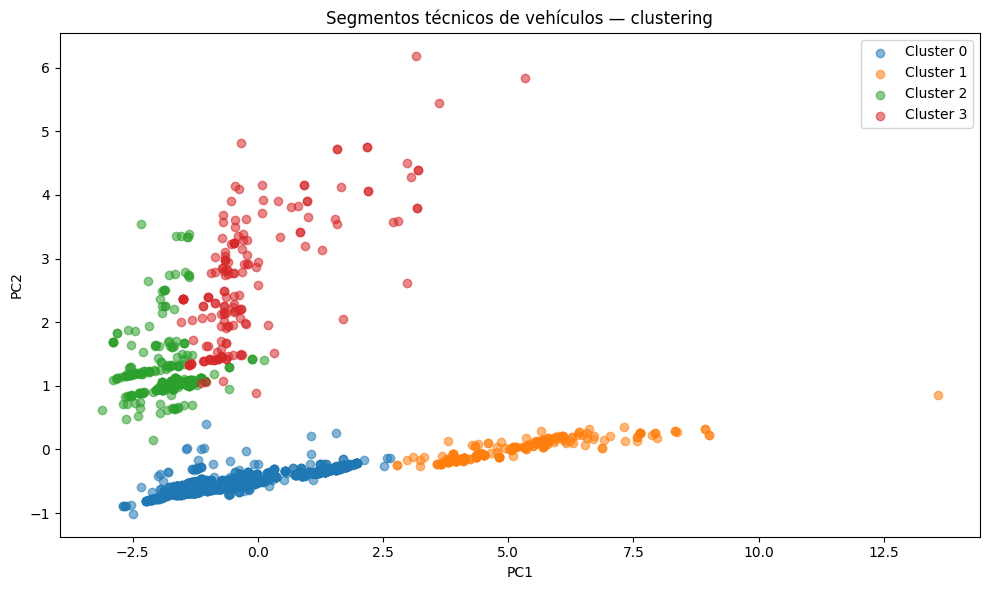

In [21]:
plt.figure(figsize=(10, 6))

for cluster_id in sorted(plot_cluster["cluster"].unique()):
    mask = plot_cluster["cluster"] == cluster_id
    plt.scatter(
        plot_cluster.loc[mask, "PC1"],
        plot_cluster.loc[mask, "PC2"],
        alpha=0.55,
        label=f"Cluster {cluster_id}"
    )

plt.title("Segmentos técnicos de vehículos — clustering")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.tight_layout()
plt.show()


## Conclusión general

El análisis sigue el enfoque planteado en el taller: **preguntar → explorar con código → observar → formular una nueva pregunta**.

La exploración muestra que Fasecolda permite estudiar diferencias de precio entre marcas y características técnicas, pero también revela problemas de calidad y disponibilidad que deben considerarse antes de construir modelos predictivos.

El siguiente paso natural sería profundizar en la preparación de datos y comparar modelos de regresión con una estrategia de validación adecuada.

El análisis exploratorio permitió identificar que el precio de los vehículos presenta una distribución asimétrica y una alta concentración de valores bajos, además de numerosos valores extremos. Se encontró una asociación positiva entre cilindraje y precio, con una correlación de Pearson de 0,701. También se observaron diferencias importantes en el precio promedio entre marcas y en el peso promedio según el fabricante. En la extensión de aprendizaje supervisado, el modelo de regresión alcanzó un R² de 0,863, mostrando una capacidad importante para explicar la variación del precio. Por otra parte, el clustering permitió identificar cuatro segmentos técnicos diferenciados sin utilizar el precio, evidenciando que las características físicas y mecánicas permiten agrupar los vehículos en perfiles distintos.
